# Un ave que vuela y bucea con las mismas alas — pero cambia de marcha

Un frailecillo bate sus alas casi 9 veces por segundo en el aire. Se lanza al mar, y sin plegarlas ni cambiarlas, sigue batiendo... pero de repente en cámara lenta.

:::{image} figuras/pixabot.png
:alt: Pixabot mascot
:width: 80px
:align: center
:figclass: pixabot-mascot
:::

**Paper:** *Leaping out of the water: Aerial-aquatic locomotion with flapping wings* — Zufferey et al., **Science** (2026)
**DOI:** [10.1126/science.aeb6744](https://doi.org/10.1126/science.aeb6744)
**Datos:** [Zenodo 10.5281/zenodo.19378356](https://doi.org/10.5281/zenodo.19378356)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-07-09-leaping-out-water-flapping-wings/notebook.ipynb)

*Video: [Pendiente]*

## Qué midieron

Hay aves —frailecillos, araos, pingüinos— que usan las **mismas alas** para volar en el aire y "volar" bajo el agua. El aire y el agua son fluidos muy distintos: el agua es unas 800 veces más densa. ¿Cómo hace un ala para servir en ambos?

Estas son aves que bucean con las alas, no con las patas (los biólogos las llaman *wing-propelled*). El equipo juntó datos de campo de esas aves y los comparó con un **robot de alas batientes** que vuela, bucea, nada y sale del agua de un salto. Aquí abrimos esos datos.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
RATIO_REFERENCIA = 3.0       # cuántas veces más lento bate el ala en agua (mediana)
COLOR_AIRE = '#2563EB'       # azul CaM — aire
COLOR_AGUA = '#059669'       # emerald — agua
COLOR_ALERTA = '#DC2626'     # rojo — referencia / robot
COLOR_REF = '#D97706'        # amber — umbral
FUENTE = 'Fuente: Zufferey et al. (2026), Science | Datos: Zenodo 10.5281/zenodo.19378356'

import os, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Estilo CaM (local → fallback GitHub raw)
BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main'
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(f'{BASE}/cam.mplstyle', style_file)
plt.style.use(style_file)

D = 'datos'
# Frecuencia de batido — 36 animales (encoding latin-1)
freq = pd.read_csv(f'{D}/flapping_frequency_animals.csv', encoding='latin-1')
freq = freq.rename(columns={'Frq air': 'aire', 'Frq wat': 'agua'})
# Solo aves wing-propelled con medición en AMBOS medios (pareadas)
pareadas = freq[freq['Type'] == 'Wing'].dropna(subset=['aire', 'agua']).copy()
pareadas['ratio'] = pareadas['aire'] / pareadas['agua']

# Robot: fuerzas de vuelo por envergadura (archivo con BOM → utf-8-sig)
vuelo = pd.read_csv(f'{D}/wingsize_flight_forces_power.csv', encoding='utf-8-sig')
# Robot: empuje al nadar por envergadura
nado = pd.read_csv(f'{D}/wingsize_swim_power.csv', encoding='latin-1')

# Costo de transporte — animales + robot (fila 0 = unidades, se descarta)
cot = pd.read_csv(f'{D}/cost_of_transport_animals.csv', encoding='latin-1').iloc[1:].copy()
cot['COT'] = pd.to_numeric(cot['COT'], errors='coerce')

print(f'Aves wing-propelled con ambos medios: {len(pareadas)}')
print(f'Batido en aire  — media: {pareadas["aire"].mean():.2f} Hz  (sd {pareadas["aire"].std(ddof=1):.2f})')
print(f'Batido en agua  — media: {pareadas["agua"].mean():.2f} Hz  (sd {pareadas["agua"].std(ddof=1):.2f})')
print(f'Ratio aire/agua — mediana: {pareadas["ratio"].median():.2f}x  (rango {pareadas["ratio"].min():.2f}-{pareadas["ratio"].max():.2f})')

Aves wing-propelled con ambos medios: 13
Batido en aire  — media: 8.41 Hz  (sd 2.05)
Batido en agua  — media: 2.84 Hz  (sd 0.79)
Ratio aire/agua — mediana: 3.00x  (rango 1.74-3.93)


## Aquí está.

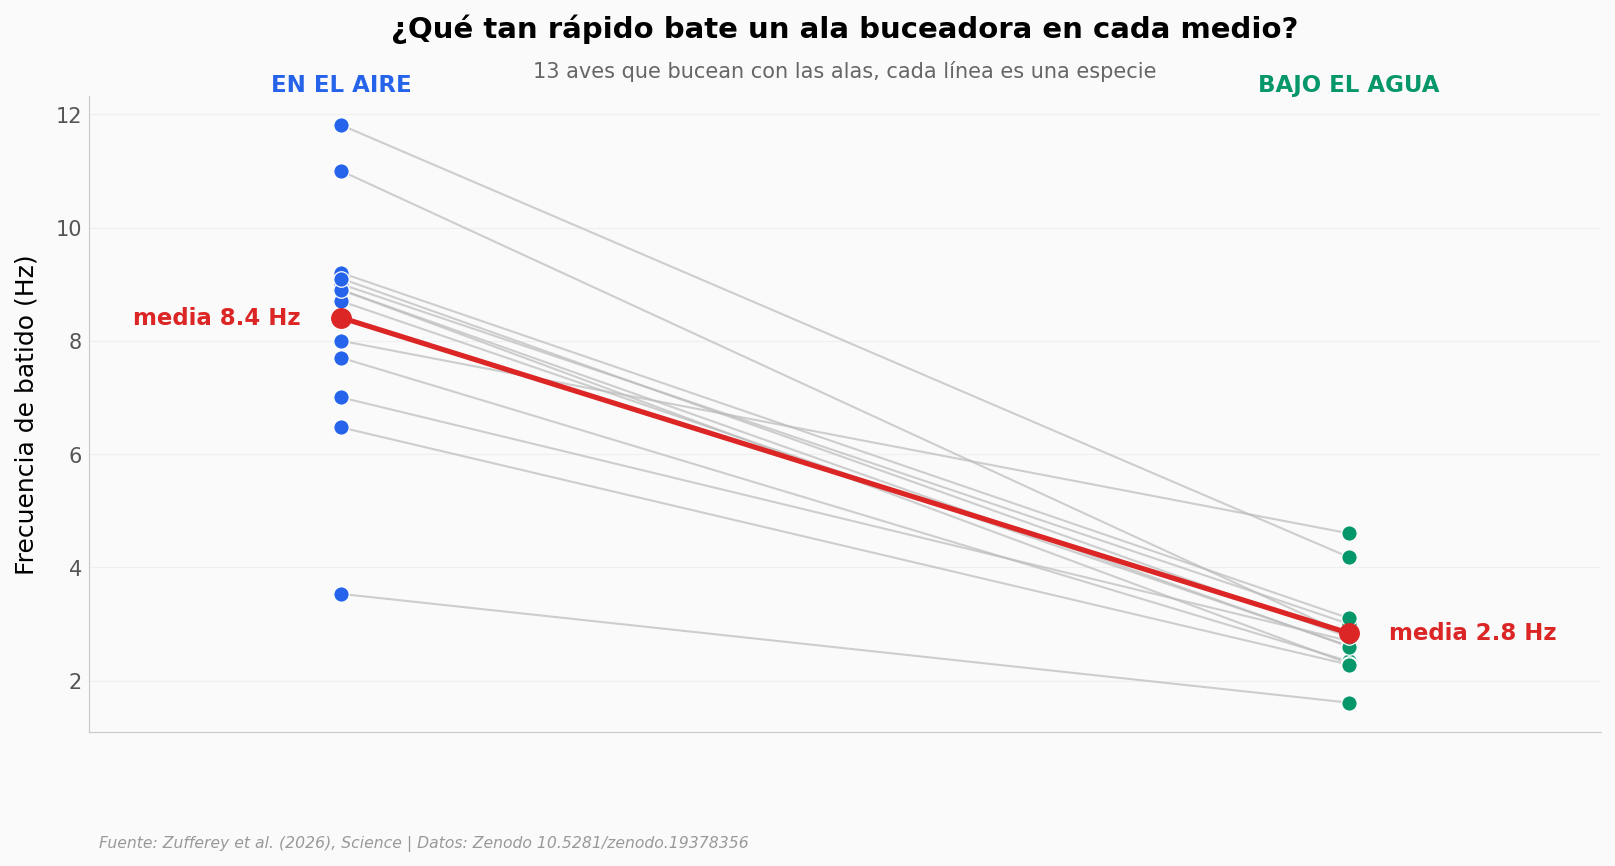

In [2]:
fig, ax = plt.subplots(figsize=(13, 5.5))

# Cada ave: una línea que baja del aire (izq) al agua (der)
for _, row in pareadas.iterrows():
    ax.plot([0, 1], [row['aire'], row['agua']], color='#BBBBBB',
            lw=1.0, alpha=0.7, zorder=2)
ax.scatter(np.zeros(len(pareadas)), pareadas['aire'], color=COLOR_AIRE,
           s=55, edgecolors='white', linewidths=0.6, zorder=5)
ax.scatter(np.ones(len(pareadas)), pareadas['agua'], color=COLOR_AGUA,
           s=55, edgecolors='white', linewidths=0.6, zorder=5)

# Medias
m_aire, m_agua = pareadas['aire'].mean(), pareadas['agua'].mean()
ax.plot([0, 1], [m_aire, m_agua], color=COLOR_ALERTA, lw=2.5, zorder=6)
ax.scatter([0, 1], [m_aire, m_agua], color=COLOR_ALERTA, s=90, zorder=7)
ax.text(-0.04, m_aire, f'media {m_aire:.1f} Hz', ha='right', va='center',
        fontsize=11, fontweight='bold', color=COLOR_ALERTA)
ax.text(1.04, m_agua, f'media {m_agua:.1f} Hz', ha='left', va='center',
        fontsize=11, fontweight='bold', color=COLOR_ALERTA)

ax.text(0, pareadas['aire'].max() + 0.6, 'EN EL AIRE', ha='center',
        fontsize=11, fontweight='bold', color=COLOR_AIRE)
ax.text(1, pareadas['aire'].max() + 0.6, 'BAJO EL AGUA', ha='center',
        fontsize=11, fontweight='bold', color=COLOR_AGUA)

ax.set_title('¿Qué tan rápido bate un ala buceadora en cada medio?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, '13 aves que bucean con las alas, cada línea es una especie',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_ylabel('Frecuencia de batido (Hz)')
ax.set_xlim(-0.25, 1.25)
ax.set_xticks([])
ax.grid(axis='y', alpha=0.4)
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/hero_frecuencia.png', dpi=200, bbox_inches='tight')
plt.show()

Lo que llama la atención: **ninguna** especie acelera bajo el agua. Todas frenan, sin excepción. Y no frenan un poquito — el batido pasa de una media de 8,41 Hz en el aire a 2,84 Hz en el agua.

La mediana de esa caída es **3 veces más lento**, y el rango va de 1,74x a 3,93x según la especie. El patrón es tan parejo que la prueba pareada de Wilcoxon da p = 0,0002, con un tamaño de efecto enorme (d de Cohen = 3,2). No es ruido: es una marcha distinta para cada fluido.

## ¿Por qué frenar? Preguntémosle a un robot

Con las aves solo se puede mirar lo que ya hacen — nadie les cambia el ala para ver qué pasa. Así que el equipo construyó un **robot de alas batientes** y sí pudo manipularlo: probó distintas envergaduras de ala para ver el conflicto entre volar bien y nadar bien.

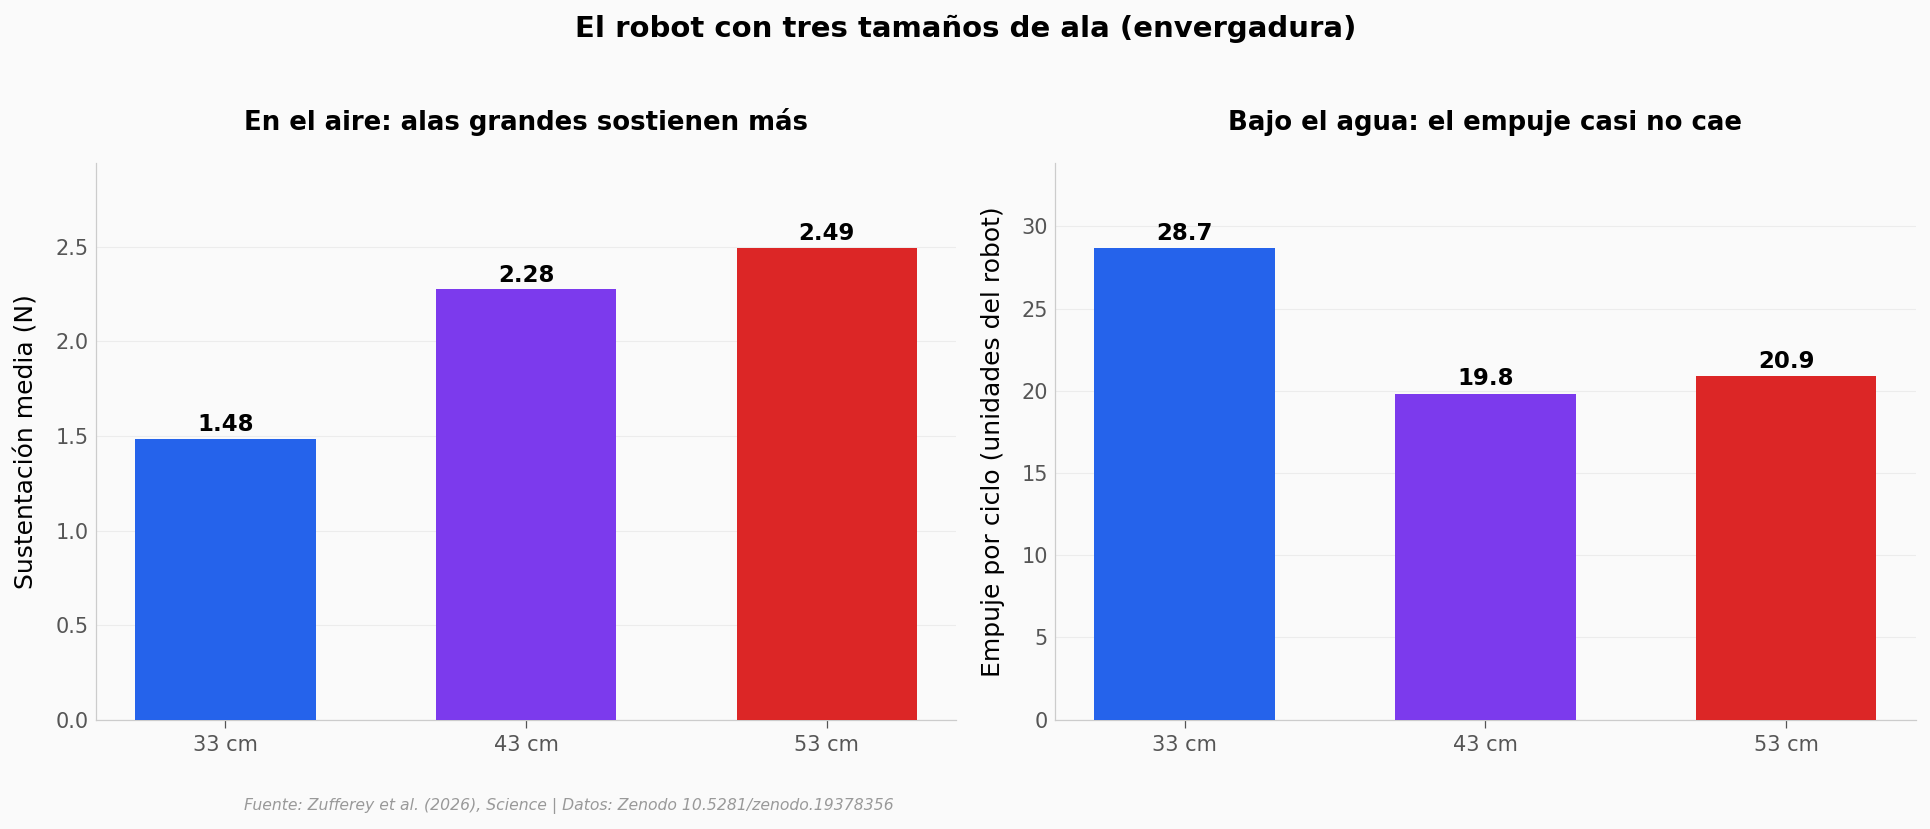

In [3]:
spans = [33, 43, 53]
lift_por_span = [vuelo[vuelo['Span'] == s]['Lift'].mean() for s in spans]
nado_por_span = [nado[nado['wingspan'] == s]['cycle_max_avg'].mean() for s in spans]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
x = np.arange(len(spans))
colores = [COLOR_AIRE, '#7C3AED', COLOR_ALERTA]

ax1.bar(x, lift_por_span, color=colores, width=0.6, zorder=3)
for xi, v in zip(x, lift_por_span):
    ax1.text(xi, v + 0.04, f'{v:.2f}', ha='center', fontsize=11, fontweight='bold')
ax1.set_title('En el aire: alas grandes sostienen más', fontsize=12.5, fontweight='bold', pad=16)
ax1.set_ylabel('Sustentación media (N)')
ax1.set_xticks(x); ax1.set_xticklabels([f'{s} cm' for s in spans])
ax1.set_ylim(0, max(lift_por_span) * 1.18)

ax2.bar(x, nado_por_span, color=colores, width=0.6, zorder=3)
for xi, v in zip(x, nado_por_span):
    ax2.text(xi, v + 0.5, f'{v:.1f}', ha='center', fontsize=11, fontweight='bold')
ax2.set_title('Bajo el agua: el empuje casi no cae', fontsize=12.5, fontweight='bold', pad=16)
ax2.set_ylabel('Empuje por ciclo (unidades del robot)')
ax2.set_xticks(x); ax2.set_xticklabels([f'{s} cm' for s in spans])
ax2.set_ylim(0, max(nado_por_span) * 1.18)

fig.suptitle('El robot con tres tamaños de ala (envergadura)',
             fontsize=14, fontweight='bold', y=1.02)
fig.text(0.13, -0.04, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/robot_envergadura.png', dpi=200, bbox_inches='tight')
plt.show()

## ¿Y el robot es tan bueno como un ave?

Un ala grande da más sustentación en el aire y, sorprendentemente, casi no le cuesta empuje bajo el agua — el conflicto que uno esperaría es mucho más suave de lo previsto. Pero "funcionar" no es lo mismo que "ser eficiente". Comparemos el **costo de transporte**: cuánta energía gasta cada uno para moverse. Cuanto más bajo, mejor.

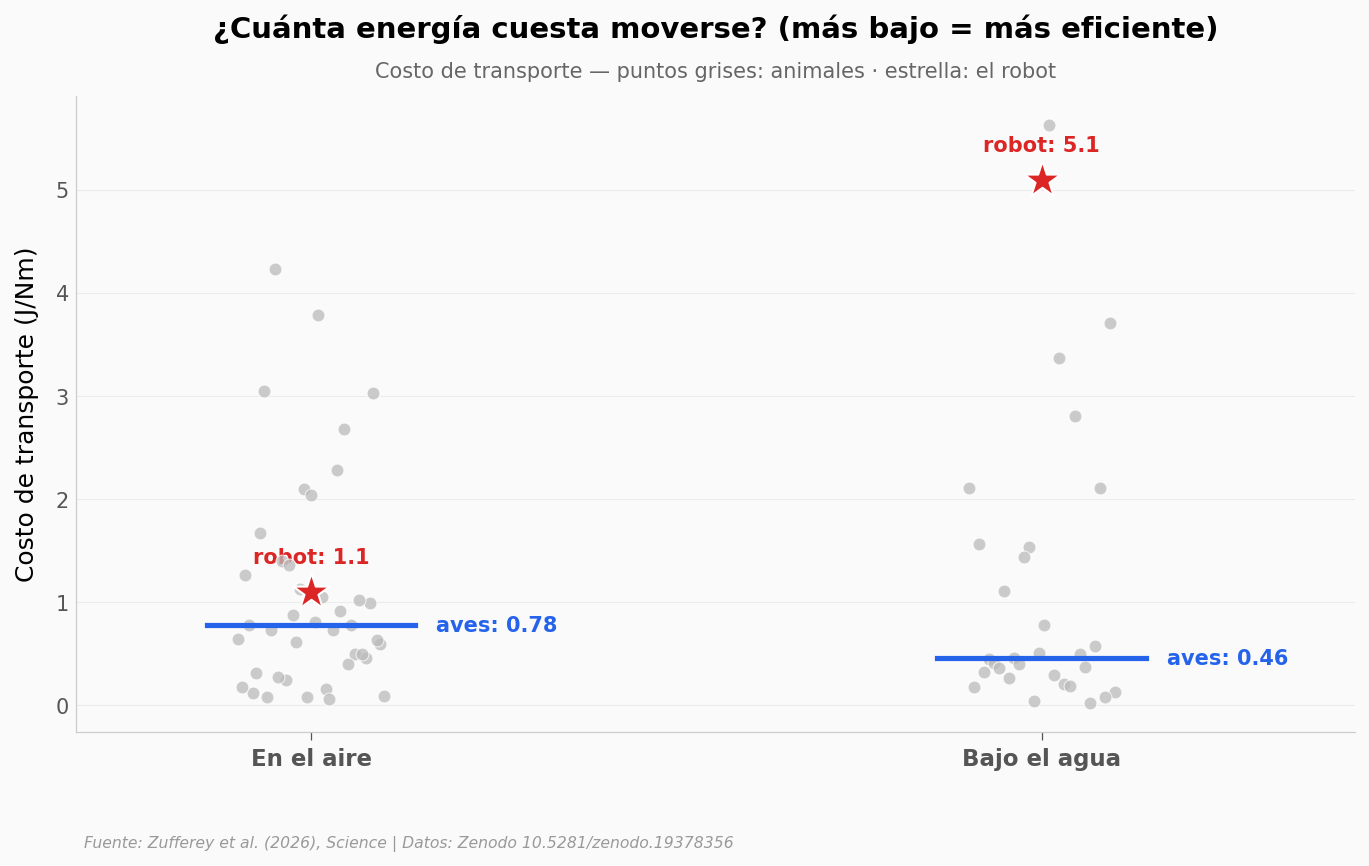

In [4]:
np.random.seed(42)
fig, ax = plt.subplots(figsize=(11, 5.5))

animales = cot[cot['type'] != 'This work']
robot = cot[cot['type'] == 'This work']
posiciones = {'air': 0, 'water': 1.4}
etiquetas = {'air': 'En el aire', 'water': 'Bajo el agua'}

for medio, pos in posiciones.items():
    vals = animales[animales['medium'] == medio]['COT'].dropna().values
    x_strip = np.linspace(pos - 0.14, pos + 0.14, len(vals))
    np.random.shuffle(x_strip)
    ax.scatter(x_strip, vals, color='#BBBBBB', s=38, alpha=0.75,
               edgecolors='white', linewidths=0.5, zorder=4, label='_')
    med = np.median(vals)
    ax.plot([pos - 0.2, pos + 0.2], [med, med], color=COLOR_AIRE, lw=2.5, zorder=6)
    ax.text(pos + 0.24, med, f'aves: {med:.2f}', va='center', fontsize=10,
            fontweight='bold', color=COLOR_AIRE)
    # Robot
    rval = robot[robot['medium'] == medio]['COT'].values[0]
    ax.scatter(pos, rval, marker='*', color=COLOR_ALERTA, s=340,
               edgecolors='white', linewidths=1.0, zorder=7)
    ax.text(pos, rval + 0.28, f'robot: {rval:.1f}', ha='center', fontsize=10,
            fontweight='bold', color=COLOR_ALERTA)

ax.set_title('¿Cuánta energía cuesta moverse? (más bajo = más eficiente)',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Costo de transporte — puntos grises: animales · estrella: el robot',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_ylabel('Costo de transporte (J/Nm)')
ax.set_xticks(list(posiciones.values()))
ax.set_xticklabels(list(etiquetas.values()), fontsize=11, fontweight='bold')
ax.set_xlim(-0.45, 2.0)
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/costo_transporte.png', dpi=200, bbox_inches='tight')
plt.show()

## ¿Qué tan parejo es ese "3 veces más lento"?

La media dice 3x, pero cada especie es su propio caso. Veamos cómo se reparte esa caída entre las 13 aves.

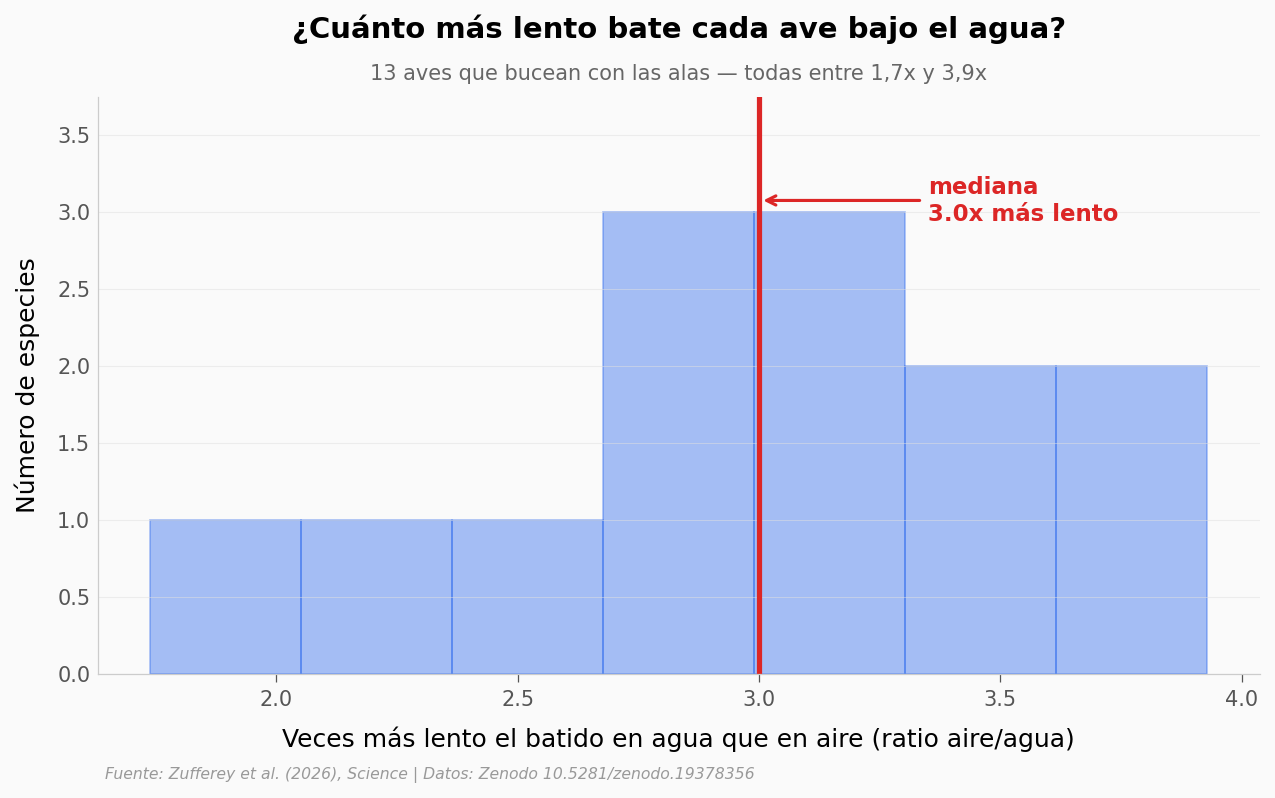

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
ratios = pareadas['ratio'].values
n, bins, patches = ax.hist(ratios, bins=7, color=COLOR_AIRE, alpha=0.4,
                           edgecolor=COLOR_AIRE, linewidth=0.8)
y_max = n.max() * 1.25
ax.set_ylim(0, y_max)

mediana = np.median(ratios)
ax.axvline(x=mediana, color=COLOR_ALERTA, linewidth=2.5)
ax.annotate(f'mediana\n{mediana:.1f}x más lento', xy=(mediana, y_max * 0.82),
            xytext=(mediana + 0.35, y_max * 0.82), fontsize=11, fontweight='bold',
            color=COLOR_ALERTA, va='center',
            arrowprops=dict(arrowstyle='->', color=COLOR_ALERTA, lw=1.5))

ax.set_title('¿Cuánto más lento bate cada ave bajo el agua?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, '13 aves que bucean con las alas — todas entre 1,7x y 3,9x',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlabel('Veces más lento el batido en agua que en aire (ratio aire/agua)')
ax.set_ylabel('Número de especies')
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/histograma_ratio.png', dpi=200, bbox_inches='tight')
plt.show()

### Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| Las aves wing-propelled baten ~3x más lento bajo el agua | ✅ | 13 aves pareadas: 8,41 Hz aire → 2,84 Hz agua. Mediana del ratio = 3,0x (rango 1,74-3,93). Wilcoxon p = 0,0002, d de Cohen = 3,2 (efecto gigante) |
| Alas más grandes sostienen más en el aire | ✅ | Robot: sustentación media sube 1,48 → 2,28 → 2,49 N al pasar de envergadura 33 a 53 (media sobre 15 condiciones por tamaño) |
| Alas grandes no sacrifican mucho empuje bajo el agua | ⚠️ | El empuje medio por ciclo baja de 28,7 (env. 33) a ~20 (env. 43-53): hay algo de costo, pero se estabiliza. El robot muestra el principio; no es un ave real |
| El robot iguala la eficiencia de un ave | ❌ | Costo de transporte del robot: 1,1 en aire (aves ~0,78) y 5,1 bajo el agua (aves ~0,46). El robot demuestra que el truco funciona, pero gasta ~10x más energía nadando |

> **Limitaciones:** la comparación entre especies es **observacional** — se miden aves en el campo, no se manipulan; el porqué del cambio de marcha se infiere. Los experimentos de envergadura y empuje vienen de **un robot**, no de aves: prueban el principio físico, no reproducen la biología. El costo de transporte del robot no es optimizado y queda lejos del de un animal.

## Ahora tú

1. **¿Qué familia frena más al bucear?** Agrupa `pareadas` por `Family` y compara la mediana del `ratio`. Pista: `pareadas.groupby('Family')['ratio'].median().sort_values()`.

2. **¿La frecuencia en aire predice la de agua?** Haz un scatter de `aire` vs `agua` y calcula la correlación de Spearman. ¿Las aves rápidas en aire son también las más rápidas en agua?

3. **¿Y si el robot fuera aún más grande?** El empuje al nadar por envergadura (`nado`) no cae en línea recta. Grafica `cycle_max_avg` contra `frequency` para cada envergadura y busca dónde el ala grande empieza a perder.

Correlación de Spearman aire vs agua: rho = 0.67  (p = 0.013)


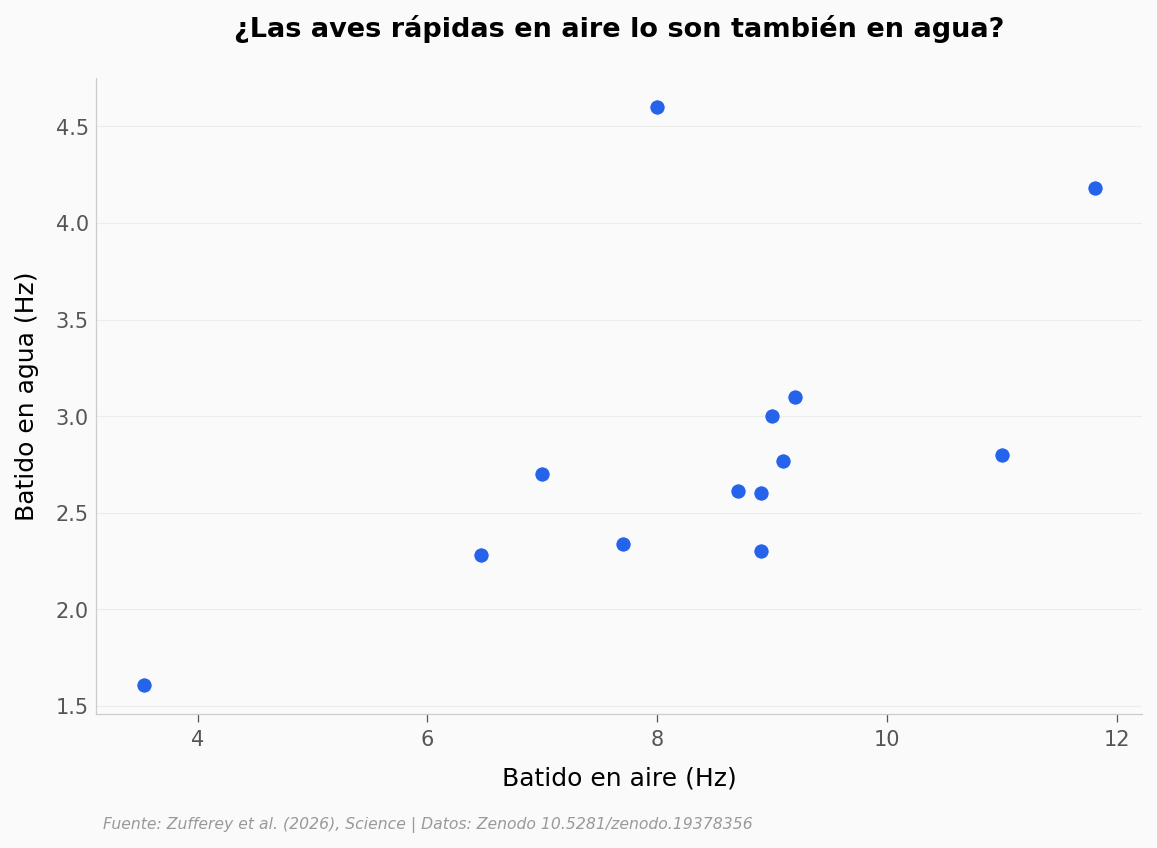

In [6]:
# --- EXPERIMENTA AQUÍ ---
# ¿La velocidad de batido en aire predice la de agua?
rho, p = stats.spearmanr(pareadas['aire'], pareadas['agua'])
print(f'Correlación de Spearman aire vs agua: rho = {rho:.2f}  (p = {p:.3f})')

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.scatter(pareadas['aire'], pareadas['agua'], color=COLOR_AIRE, s=55,
           edgecolors='white', linewidths=0.5, zorder=5)
ax.set_title('¿Las aves rápidas en aire lo son también en agua?',
             fontsize=13, fontweight='bold', pad=20)
ax.set_xlabel('Batido en aire (Hz)')
ax.set_ylabel('Batido en agua (Hz)')
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.show()

## Fuentes

**Paper**: [Leaping out of the water: Aerial-aquatic locomotion with flapping wings](https://doi.org/10.1126/science.aeb6744)  
*Science, 2026-07-09*

**Datos**: [Data for: Leaping out of the water: aerial-aquatic locomotion with flapping wings](https://doi.org/10.5281/zenodo.19378356)

*13 afirmaciones del notebook verificadas contra estas fuentes*

---

*Notebook reproducible de [Ciencia a Mordiscos](https://cienciaamordiscos.com). Licencia de los datos: ver Zenodo. Repo: [github.com/Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab).*